# Data Mining Project : Outlier Detection with Data Depth

Loan Rottier, Maëlys Rapenne and Simon Simus

## Import packages

In [1]:
from scipy.io import arff
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from depth.model import DepthEucl
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

from depth.model.DepthEucl import DepthEucl


## Import and preprocess data

In [2]:
def load_data():
    data, meta = arff.loadarff("data\WBC_withoutdupl_v01.arff")
    df = pd.DataFrame(data)

    # cleaning byte strings to normal strings
    for col in df.select_dtypes([object]):
        df[col] = df[col].str.decode("utf-8")

    print(df.describe())
    # print("Columns available :", df.columns.tolist())
    target_col = df.columns[-1]

    # transformr outlier into 0: normal, 1: anomaly
    y = np.where(df[target_col] == "yes", 1, 0).astype(int)
    cols_to_drop = ["outlier", "id"]
    X_raw = df.drop(columns=cols_to_drop).values.astype(float)

    scaler = StandardScaler()
    X = scaler.fit_transform(X_raw)
    return X, y

X, y = load_data()


             att2        att3        att4        att5        att6        att7  \
count  223.000000  223.000000  223.000000  223.000000  223.000000  223.000000   
mean     3.506726    1.860987    1.982063    1.834081    2.443946    2.013453   
std      1.919248    1.672096    1.662962    1.609181    1.441110    2.163330   
min      1.000000    1.000000    1.000000    1.000000    1.000000    1.000000   
25%      2.000000    1.000000    1.000000    1.000000    2.000000    1.000000   
50%      3.000000    1.000000    1.000000    1.000000    2.000000    1.000000   
75%      5.000000    2.000000    2.000000    2.000000    2.000000    2.000000   
max     10.000000   10.000000   10.000000   10.000000   10.000000   10.000000   

             att8        att9       att10          id  
count  223.000000  223.000000  223.000000  223.000000  
mean     2.408072    1.784753    1.139013  330.860987  
std      1.610586    1.857136    0.725006  209.394480  
min      1.000000    1.000000    1.000000    1

<>:2: SyntaxWarning: invalid escape sequence '\W'
<>:2: SyntaxWarning: invalid escape sequence '\W'
C:\Users\simus\AppData\Local\Temp\ipykernel_22148\1334597612.py:2: SyntaxWarning: invalid escape sequence '\W'
  data, meta = arff.loadarff("data\WBC_withoutdupl_v01.arff")


## Part 1 : Depth functions with generated data :

Generate data in 2 dimensions. Only 2 dimensions because it's easier to visualize it

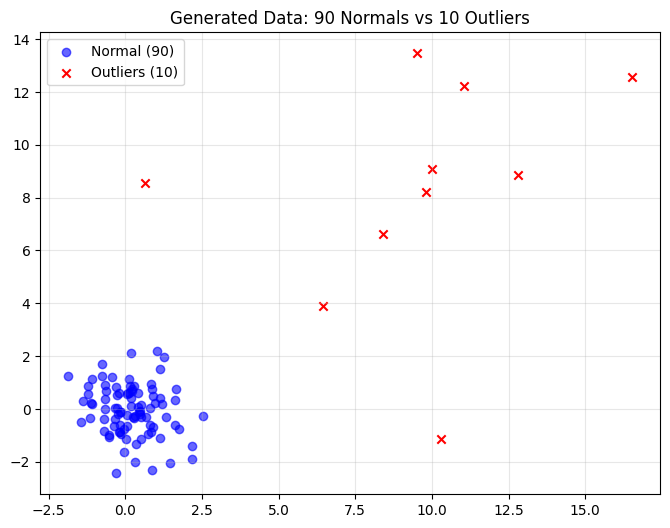

In [16]:
np.random.seed(1)

# Genrate 90 with N((0,0),I2) and 10 outliers with N((7,7),I2)

X_normal = np.random.normal(loc=0, scale=1, size=(90, 2))
y_normal = np.zeros(90) # Label 0 for normal

X_outliers = np.random.normal(loc=7, scale=5, size=(10, 2))
y_outliers = np.ones(10)  # Label 1 for outlier


X_generated = np.concatenate([X_normal, X_outliers])
y_generated = np.concatenate([y_normal, y_outliers])

# Visualize the generated data
plt.figure(figsize=(8, 6))
plt.scatter(X_generated[y_generated==0, 0], X_generated[y_generated==0, 1], c='blue', label='Normal (90)', alpha=0.6)
plt.scatter(X_generated[y_generated==1, 0], X_generated[y_generated==1, 1], c='red', marker='x', label='Outliers (10)')
plt.title("Generated Data: 90 Normals vs 10 Outliers")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Try 4 depths functions without train test split : projection depth, simplicial volume, simplicial and half space depth

### Simplicial volume depth

x value is set to the loaded dataset


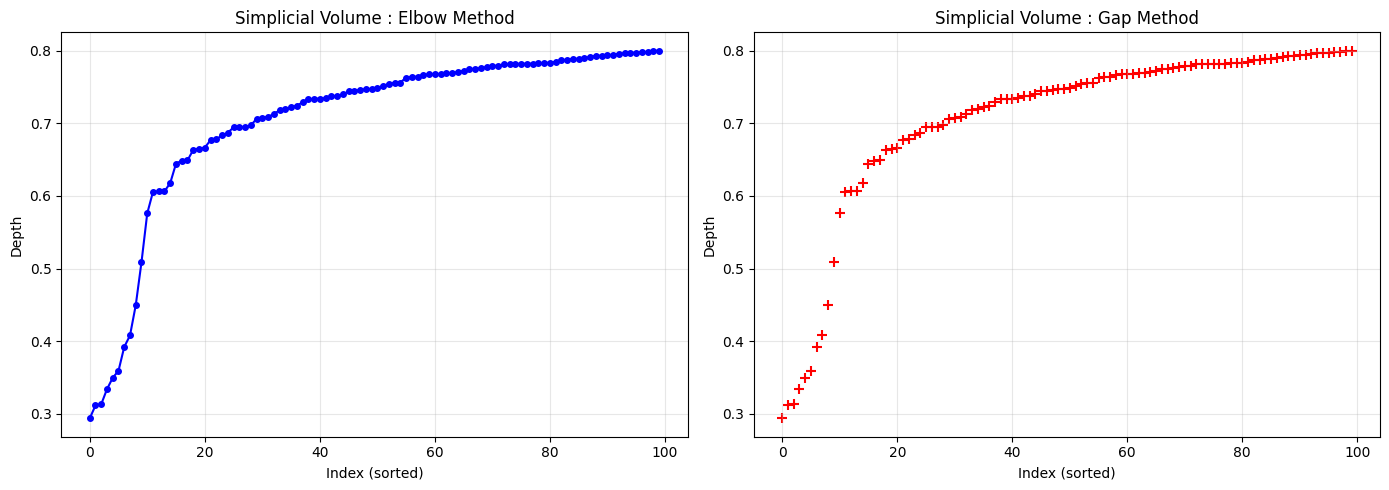

In [17]:
model=DepthEucl().load_dataset(X_generated)
depthX=model.simplicialVolume(X_generated)

# We evaluate the dataset itself (calculate the depth of X with respect to X)
# exact=True is fast here because we are in 2D with few points
depth_scores = model.simplicialVolume(evaluate_dataset=True, exact=True)

def plot_thresholds(scores):
    # sorted scores
    scores_sorted = np.sort(scores)
    
    index = np.arange(len(scores_sorted))
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # ELBOW plot
    ax1.plot(index, scores_sorted, 'b-o', markersize=4)
    ax1.set_title("Simplicial Volume : Elbow Method")
    ax1.set_xlabel("Index (sorted)")
    ax1.set_ylabel("Depth")
    ax1.grid(True, alpha=0.3)
    
    # GAP plot
    ax2.scatter(index, scores_sorted, c='red', marker='+', s=60)
    ax2.set_title("Simplicial Volume : Gap Method")
    ax2.set_xlabel("Index (sorted)")
    ax2.set_ylabel("Depth")
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_thresholds(depth_scores)

For the Gap method we can see a gap close to 9-11 in index. We can choose a threshold of 0.45 (complicated to find). 
For Elbow method we can see thath at index 12 we have a change in points tendency, so we can choose 0.6 for the threshold.

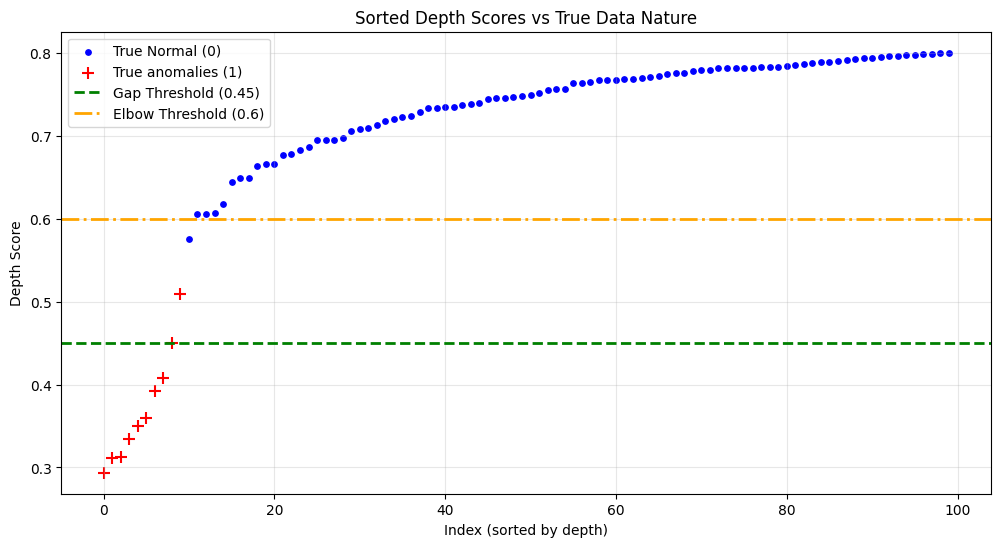

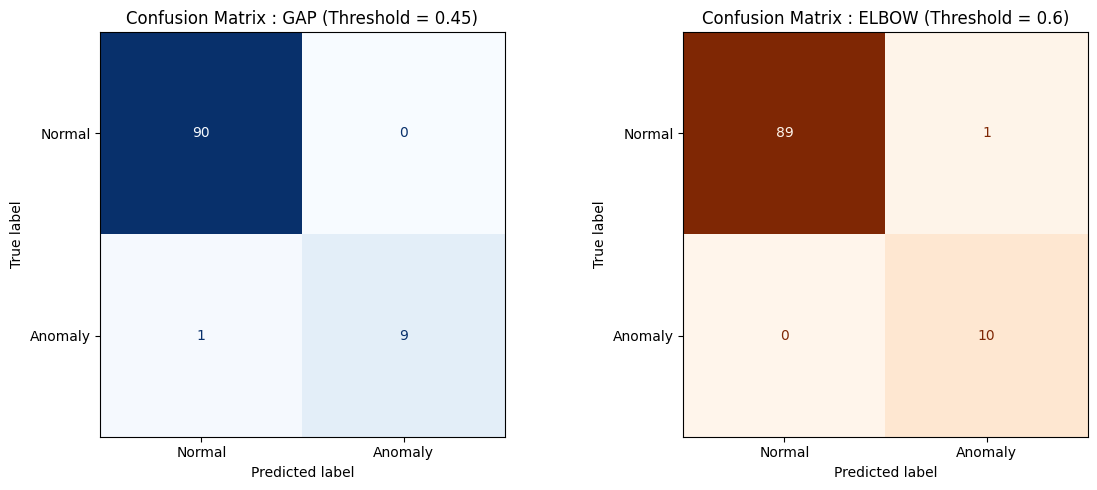

In [19]:
threshold_gap = 0.45
threshold_elbow = 0.6


y_pred_gap = np.where(depth_scores < threshold_gap, 1, 0)
y_pred_elbow = np.where(depth_scores < threshold_elbow, 1, 0)



sorted_indices = np.argsort(depth_scores)
scores_sorted = depth_scores[sorted_indices]
y_sorted = y_generated[sorted_indices]

fig, ax = plt.subplots(figsize=(12, 6))

#we display normal points (true) in BLUE and anomalies (true) in RED
# this allows to see how well the depth scores separate the two classes
ax.scatter(np.arange(len(y_generated))[y_sorted==0], scores_sorted[y_sorted==0], 
           c='blue', s=15, label='True Normal (0)')
ax.scatter(np.arange(len(y_generated))[y_sorted==1], scores_sorted[y_sorted==1], 
           c='red', marker='+', s=80, label='True anomalies (1)')

# Add threshold lines
ax.axhline(y=threshold_gap, color='green', linestyle='--', linewidth=2, label=f'Gap Threshold ({threshold_gap})')
ax.axhline(y=threshold_elbow, color='orange', linestyle='-.', linewidth=2, label=f'Elbow Threshold ({threshold_elbow})')

ax.set_title("Sorted Depth Scores vs True Data Nature")
ax.set_xlabel("Index (sorted by depth)")
ax.set_ylabel("Depth Score")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


#confusion matrices for both methods
from sklearn.metrics import ConfusionMatrixDisplay
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Matrice Gap
cm_gap = confusion_matrix(y_generated, y_pred_gap)
disp_gap = ConfusionMatrixDisplay(confusion_matrix=cm_gap, display_labels=['Normal', 'Anomaly'])
disp_gap.plot(ax=ax1, cmap='Blues', colorbar=False)
ax1.set_title(f"Confusion Matrix : GAP (Threshold = {threshold_gap})")

# Matrice Elbow
cm_elbow = confusion_matrix(y_generated, y_pred_elbow)
disp_elbow = ConfusionMatrixDisplay(confusion_matrix=cm_elbow, display_labels=['Normal', 'Anomaly'])
disp_elbow.plot(ax=ax2, cmap='Oranges', colorbar=False)
ax2.set_title(f"Confusion Matrix : ELBOW (Threshold = {threshold_elbow})")

plt.tight_layout()
plt.show()

Since we have a big difference between anomalies and normal data the simplicial volume have very good result. 9 anomaly detected with gap theshold and 10 for elbow theshold. 1 FP for gap and 1 FN for elbow threshold. 

### Simplicial depth


x value is set to the loaded dataset


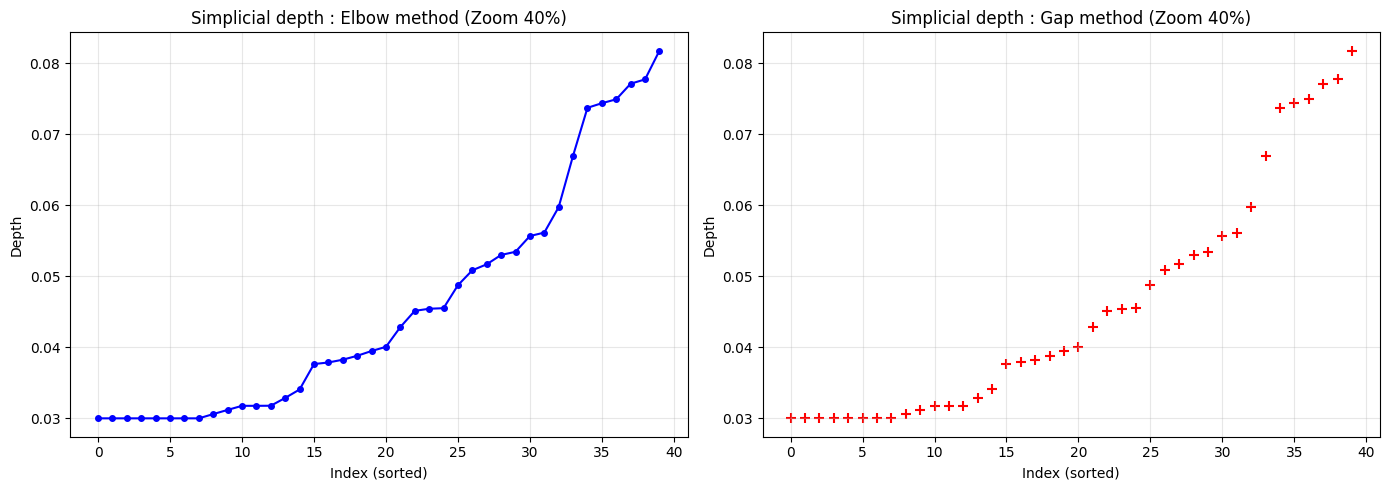

In [22]:
model=DepthEucl().load_dataset(X_generated)
depthX=model.simplicial(X_generated)

# We evaluate the dataset itself (calculate the depth of X with respect to X)
# exact=True is fast here because we are in 2D with few points
depth_scores = model.simplicial(evaluate_dataset=True, exact=True)

def plot_thresholds(scores):
    # sorted scores
    scores_sorted = np.sort(scores)
    
    # Zoom on the lowest 40% to better see anomalies
    n_zoom = int(len(scores) * 0.40)
    scores_zoom = scores_sorted[:n_zoom]
    index = np.arange(n_zoom)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # ELBOW plot
    ax1.plot(index, scores_zoom, 'b-o', markersize=4)
    ax1.set_title("Simplicial depth : Elbow method (Zoom 40%)")
    ax1.set_xlabel("Index (sorted)")
    ax1.set_ylabel("Depth")
    ax1.grid(True, alpha=0.3)
    
    # GAP plot
    ax2.scatter(index, scores_zoom, c='red', marker='+', s=60)
    ax2.set_title("Simplicial depth : Gap method (Zoom 40%)")
    ax2.set_xlabel("Index (sorted)")
    ax2.set_ylabel("Depth")
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
plot_thresholds(depth_scores)

 With this method it is very complicated to identify a good theshold. So we decided to zoom such in the article to find more accurately the theshold. For Elbow and gap method we can find a difference close to 14 in index and choose 0.035

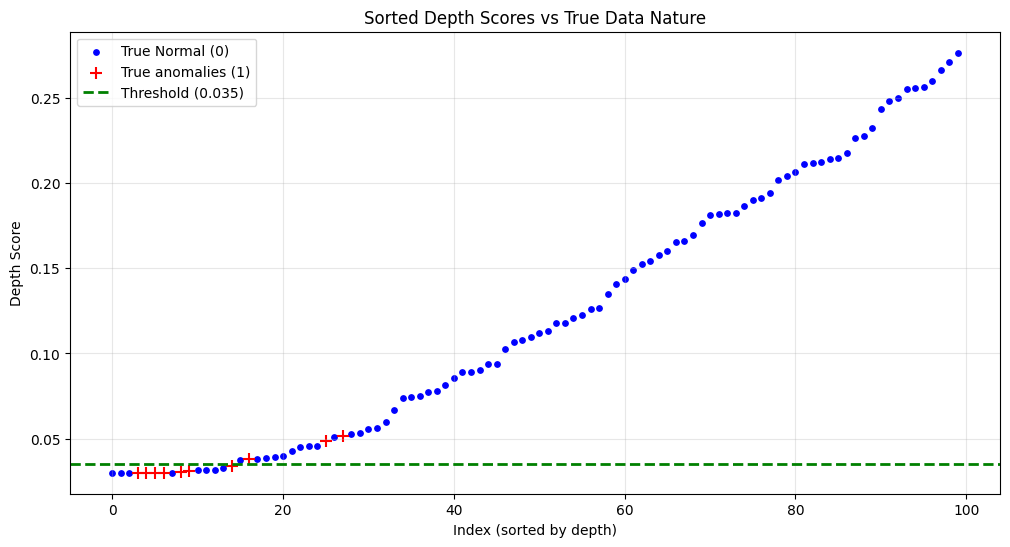

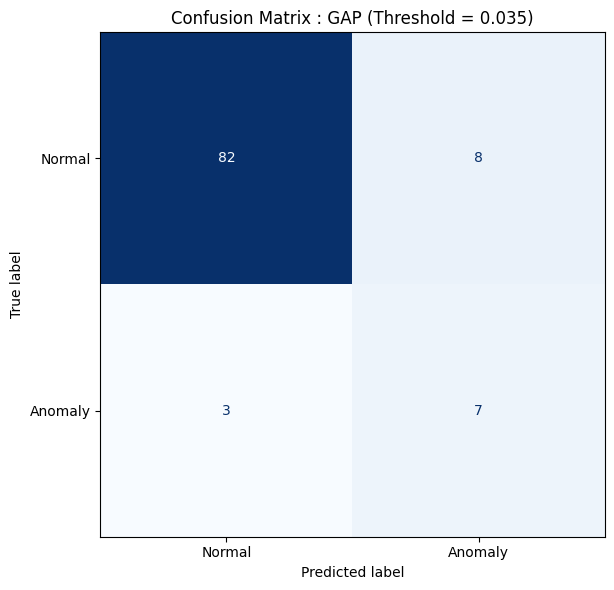

In [24]:
threshold = 0.035


y_pred = np.where(depth_scores < threshold, 1, 0)




sorted_indices = np.argsort(depth_scores)
scores_sorted = depth_scores[sorted_indices]
y_sorted = y_generated[sorted_indices]

fig, ax = plt.subplots(figsize=(12, 6))

#we display normal points (true) in BLUE and anomalies (true) in RED
# this allows to see how well the depth scores separate the two classes
ax.scatter(np.arange(len(y_generated))[y_sorted==0], scores_sorted[y_sorted==0], 
           c='blue', s=15, label='True Normal (0)')
ax.scatter(np.arange(len(y_generated))[y_sorted==1], scores_sorted[y_sorted==1], 
           c='red', marker='+', s=80, label='True anomalies (1)')

# Add threshold lines
ax.axhline(y=threshold, color='green', linestyle='--', linewidth=2, label=f'Threshold ({threshold})')

ax.set_title("Sorted Depth Scores vs True Data Nature")
ax.set_xlabel("Index (sorted by depth)")
ax.set_ylabel("Depth Score")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()



fig, ax = plt.subplots(figsize=(12, 6))

# Matrice Gap
cm_gap = confusion_matrix(y_generated, y_pred)
disp_gap = ConfusionMatrixDisplay(confusion_matrix=cm_gap, display_labels=['Normal', 'Anomaly'])
disp_gap.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f"Confusion Matrix : GAP (Threshold = {threshold})")

plt.tight_layout()
plt.show()

Result are worse than with simplicial volume. It can be explain that some true generated data can be far from other value such it can be in multivariate normal density. Some anomalies are grouped and can be considered such as normal data

### Half space depth

x value is set to the loaded dataset


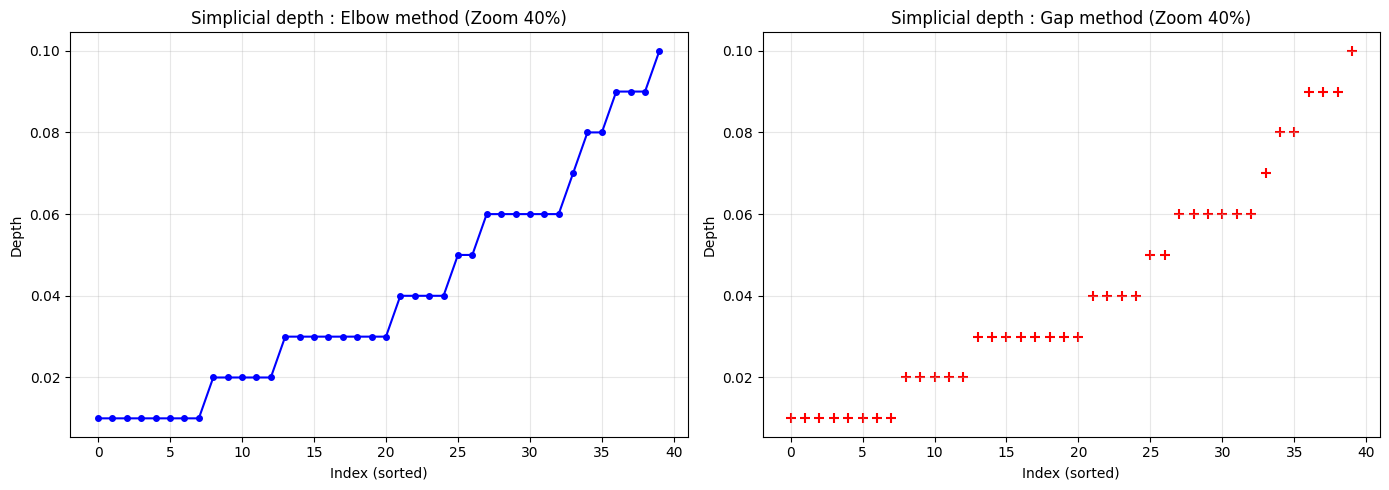

In [ ]:
model=DepthEucl().load_dataset(X_generated)
depthX=model.halfspace(X_generated)

# We evaluate the dataset itself (calculate the depth of X with respect to X)
# exact=True is fast here because we are in 2D with few points
depth_scores = model.halfspace(evaluate_dataset=True, exact=True)
def plot_thresholds(scores):
    # sorted scores
    scores_sorted = np.sort(scores)
    
    # Zoom on the lowest 40% to better see anomalies
    n_zoom = int(len(scores) * 0.40)
    scores_zoom = scores_sorted[:n_zoom]
    index = np.arange(n_zoom)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # ELBOW plot
    ax1.plot(index, scores_zoom, 'b-o', markersize=4)
    ax1.set_title("halfspace depth : Elbow method (Zoom 40%)")
    ax1.set_xlabel("Index (sorted)")
    ax1.set_ylabel("Depth")
    ax1.grid(True, alpha=0.3)
    
    # GAP plot
    ax2.scatter(index, scores_zoom, c='red', marker='+', s=60)
    ax2.set_title("halfspace depth : Gap method (Zoom 40%)")
    ax2.set_xlabel("Index (sorted)")
    ax2.set_ylabel("Depth")
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
plot_thresholds(depth_scores)

Complicated to find a threshold for both method. We can try close to 7 and 12 in index : 0.015 and 0.021

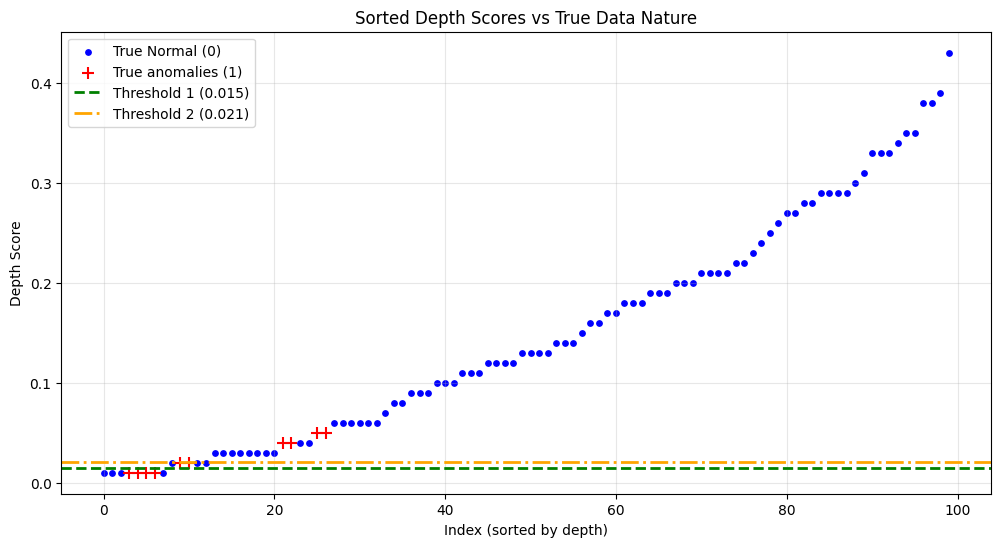

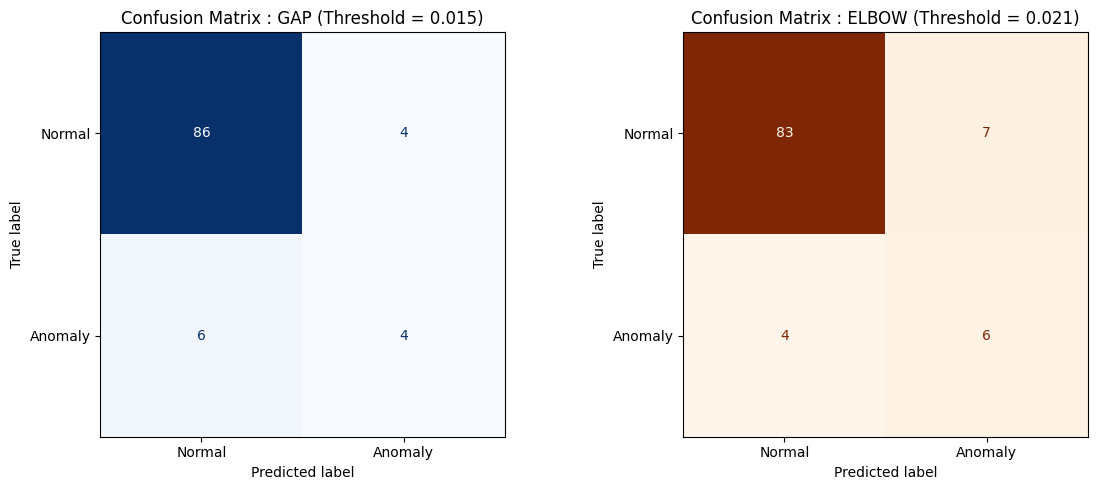

In [ ]:
threshold_1 = 0.015
threshold_2 = 0.021


y_pred_1 = np.where(depth_scores < threshold_1, 1, 0)
y_pred_2 = np.where(depth_scores < threshold_2, 1, 0)



sorted_indices = np.argsort(depth_scores)
scores_sorted = depth_scores[sorted_indices]
y_sorted = y_generated[sorted_indices]

fig, ax = plt.subplots(figsize=(12, 6))

#we display normal points (true) in BLUE and anomalies (true) in RED
# this allows to see how well the depth scores separate the two classes
ax.scatter(np.arange(len(y_generated))[y_sorted==0], scores_sorted[y_sorted==0], 
           c='blue', s=15, label='True Normal (0)')
ax.scatter(np.arange(len(y_generated))[y_sorted==1], scores_sorted[y_sorted==1], 
           c='red', marker='+', s=80, label='True anomalies (1)')

# Add threshold lines
ax.axhline(y=threshold_1, color='green', linestyle='--', linewidth=2, label=f'Threshold 1 ({threshold_1})')
ax.axhline(y=threshold_2, color='orange', linestyle='-.', linewidth=2, label=f'Threshold 2 ({threshold_2})')

ax.set_title("Sorted Depth Scores vs True Data Nature")
ax.set_xlabel("Index (sorted by depth)")
ax.set_ylabel("Depth Score")
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()


#confusion matrices for both methods
from sklearn.metrics import ConfusionMatrixDisplay
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Matrice Gap
cm_gap = confusion_matrix(y_generated, y_pred_1)
disp_gap = ConfusionMatrixDisplay(confusion_matrix=cm_gap, display_labels=['Normal', 'Anomaly'])
disp_gap.plot(ax=ax1, cmap='Blues', colorbar=False)
ax1.set_title(f"Confusion Matrix : (Threshold = {threshold_1})")

# Matrice Elbow
cm_elbow = confusion_matrix(y_generated, y_pred_2)
disp_elbow = ConfusionMatrixDisplay(confusion_matrix=cm_elbow, display_labels=['Normal', 'Anomaly'])
disp_elbow.plot(ax=ax2, cmap='Oranges', colorbar=False)
ax2.set_title(f"Confusion Matrix : (Threshold = {threshold_2})")

plt.tight_layout()
plt.show()

We detect some anomaly but we have in both thesholds FP and FN

### Projection Space depth

In [ ]:
model=DepthEucl().load_dataset(X_generated)
depthX=model.projection(X_generated)

# We evaluate the dataset itself (calculate the depth of X with respect to X)
# exact=True is fast here because we are in 2D with few points
depth_scores = model.projection(evaluate_dataset=True, exact=True)

def plot_thresholds(scores):
    # sorted scores
    scores_sorted = np.sort(scores)
    
    index = np.arange(len(scores_sorted))
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    # ELBOW plot
    ax1.plot(index, scores_sorted, 'b-o', markersize=4)
    ax1.set_title("Projection : Elbow Method")
    ax1.set_xlabel("Index (sorted)")
    ax1.set_ylabel("Depth")
    ax1.grid(True, alpha=0.3)
    
    # GAP plot
    ax2.scatter(index, scores_sorted, c='red', marker='+', s=60)
    ax2.set_title("Projection : Gap Method")
    ax2.set_xlabel("Index (sorted)")
    ax2.set_ylabel("Depth")
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_thresholds(depth_scores)